# Config B — Continuous-State ICU-Sepsis (Deep RL)

This notebook **loads committed results** produced by `regenerate_configB.py`
from the 1 M Optuna-tuned models (DQN, PPO, A2C). All cells read from
`configB_1m_results.json` and `plots/` — **no training or GPU is required**.

**Action space** `Discrete(25)` (5 vasopressor × 5 IV-fluid levels) — identical to
Config A. The **observation** is a continuous 47-dim clinical feature vector, so we
use the discrete-action deep-RL algorithms DQN, PPO, A2C.

---
| Section | Content |
|---------|---------|
| 1 | Environment & configuration |
| 2 | **Headline results** — 1 M Optuna-tuned agents (no shaping) |
| 3 | **Creative extensions** — LfD/BC, clinical interpretability |
| 4 | **Ablations** — SOFA reward shaping, hyperparameter tuning |

---
### Group Members

Name of the Group: ICU-Sepsis RL

```
Gonçalo Gomes Arrobas (20250421)
Maria Tavares Pimentel (20250466)
Tiago Stubner Lucas Antunes (20250357)
```

In [70]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import sepsis_rl as srl

srl.ensure_dirs(srl.OUTPUT_DIR, srl.MODELS_DIR, srl.LOGS_DIR)
print('Device           :', srl.DEVICE)
print('Plots saved to   :', srl.OUTPUT_DIR + '/')
print('Algorithms       :', list(srl.ALGOS))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Device           : cuda
Plots saved to   : outputs/
Algorithms       : ['DQN', 'PPO', 'A2C']


## 1. Environment & Configuration

`make_clinical_env` stacks three failure-mode wrappers on the 47-dim continuous
base environment:

| Wrapper | Failure mode | Probability |
|---------|-------------|------------|
| `EpisodicNoisyObsEnv` | Monitor malfunction — Gaussian noise on all observations | 15 % of episodes |
| `EpisodicMissingObsEnv` | Missing labs — 4 features zeroed for the whole episode | 15 % of episodes |
| `AcuteEventEnv` | Sudden death — episode terminates immediately | 1 % per step |

The random-policy and clinician-expert baselines are loaded from the committed
results file — no re-evaluation needed.

In [71]:
import json as _j
from envs.wrappers import make_clinical_env

env = make_clinical_env()
print("Observation space:", env.observation_space)
print("Action space     :", env.action_space)
env.close()

# Baselines from committed configB_1m_results.json (no retraining needed)
_s = _j.load(open("configB_1m_results.json"))
RANDOM_RETURN = _s["random"]["All"]["return"]
RANDOM_SURV   = _s["random"]["All"]["survival"]
EXPERT_SURV   = _s["expert"]["All"]["survival"]
print(f"Random baseline  : return={RANDOM_RETURN:.4f}  survival={RANDOM_SURV:.1%}")
print(f"Expert baseline  : survival={EXPERT_SURV:.1%}")

make_sepsis_env | lam=0.02 -> intensity penalty active
make_sepsis_env | sofa_bias=5.0 -> mean start SOFA: 9.02
Observation space: Box(-inf, inf, (47,), float32)
Action space     : Discrete(25)
Random baseline  : return=0.5485  survival=63.7%
Expert baseline  : survival=63.9%


## 2. Headline Results — 1 M Optuna-Tuned Agents

The three deep-RL agents (DQN, PPO, A2C) were trained for **1 000 000 steps** using
Optuna-selected hyperparameters and **VecNormalize** observation normalisation.
Training and evaluation both use `make_clinical_env()` with the **true unmodified
reward** (the reward-shaping ablation is in §4.1 and does not affect these numbers).

Results are loaded from `configB_1m_results.json`; figures from `plots/`.

### 2.1 Algorithms: DQN, PPO, A2C

All three algorithms share the **Discrete(25)** action space from Config A; only the
*observation* changes — a continuous 47-dim clinical feature vector replaces the scalar
state index. **VecNormalize** standardises each feature to zero mean and unit variance
using a running estimate over training transitions.

---

#### Deep Q-Network (DQN) — value-based, off-policy  *(Mnih et al., 2015)*

A Q-network $Q(s,a;\theta)$ minimises the squared Bellman residual over a
**replay buffer** $\mathcal{D}$:

$$\mathcal{L}(\theta) = \mathbb{E}_{(s,a,r,s')\sim\mathcal{D}}\!
\left[\Bigl(r + \gamma\,\max_{a'}Q(s',a';\,\theta^{-})
- Q(s,a;\theta)\Bigr)^{2}\right]$$

A **frozen target network** $\theta^{-}$ (periodically synced) decouples the
prediction from its own target and stabilises training.
$\varepsilon$-greedy exploration anneals linearly from 1.0 to 0.05.

---

#### Proximal Policy Optimisation (PPO) — on-policy, clipped  *(Schulman et al., 2017)*

PPO maximises a **clipped surrogate objective** that prevents destructively large
policy updates:

$$\mathcal{L}^{\text{CLIP}}(\theta)=\mathbb{E}_t\!\left[
\min\!\left(\rho_t(\theta)\,\hat{A}_t,\;
\operatorname{clip}\!\left(\rho_t(\theta),\,1{-}\varepsilon,\,1{+}\varepsilon\right)
\hat{A}_t\right)\right],
\quad\rho_t = \frac{\pi_{\theta}(a_t|s_t)}{\pi_{\theta_{\mathrm{old}}}(a_t|s_t)}$$

The advantage $\hat{A}_t$ is estimated with **Generalised Advantage Estimation**
(GAE, Schulman et al., 2016; $\lambda=0.95$). Multiple mini-batch epochs per rollout
improve sample efficiency over vanilla policy gradient.

---

#### Advantage Actor-Critic (A2C) — on-policy, unclipped

A2C applies the policy-gradient theorem with a learned value baseline to reduce
variance:

$$\nabla_{\theta}J(\theta)=\mathbb{E}_t\!\left[
\nabla_{\theta}\log\pi_{\theta}(a_t|s_t)\cdot\hat{A}_t\right],
\quad\hat{A}_t = G_t - V_{\phi}(s_t)$$

A single gradient step per rollout with no clipping makes A2C simpler than PPO at the
cost of higher variance. It acts as a direct **ablation of PPO's clipping mechanism**.

---

#### Design rationale

| Algorithm | Off/On-policy | Key mechanism | Rationale for inclusion |
|-----------|:------------:|---------------|------------------------|
| DQN | Off-policy | Replay buffer + target network | Data-efficient; stable Q-estimation on sparse reward |
| PPO | On-policy | Clipped surrogate + GAE | State-of-the-art policy gradient; good with noisy obs |
| A2C | On-policy | Unclipped policy gradient | Ablation of clipping; lightweight second policy-gradient baseline |

$\gamma = 1.0$ throughout — consistent with Config A and the ICU-Sepsis paper:
only the terminal outcome (survival or death) matters, not when it occurs.

In [ ]:
from IPython.display import Image, display

# DQN exploration schedule (epsilon-greedy decay, 1M steps).
# epsilon decays linearly from 1.0 to 0.05 over the first 200k steps (20% of training),
# then stays constant at 0.05 -- guaranteeing 5% random exploration throughout.
# PPO and A2C use stochastic policies (entropy bonus) -- no epsilon parameter.
display(Image('plots/configB_epsilon_decay.png'))

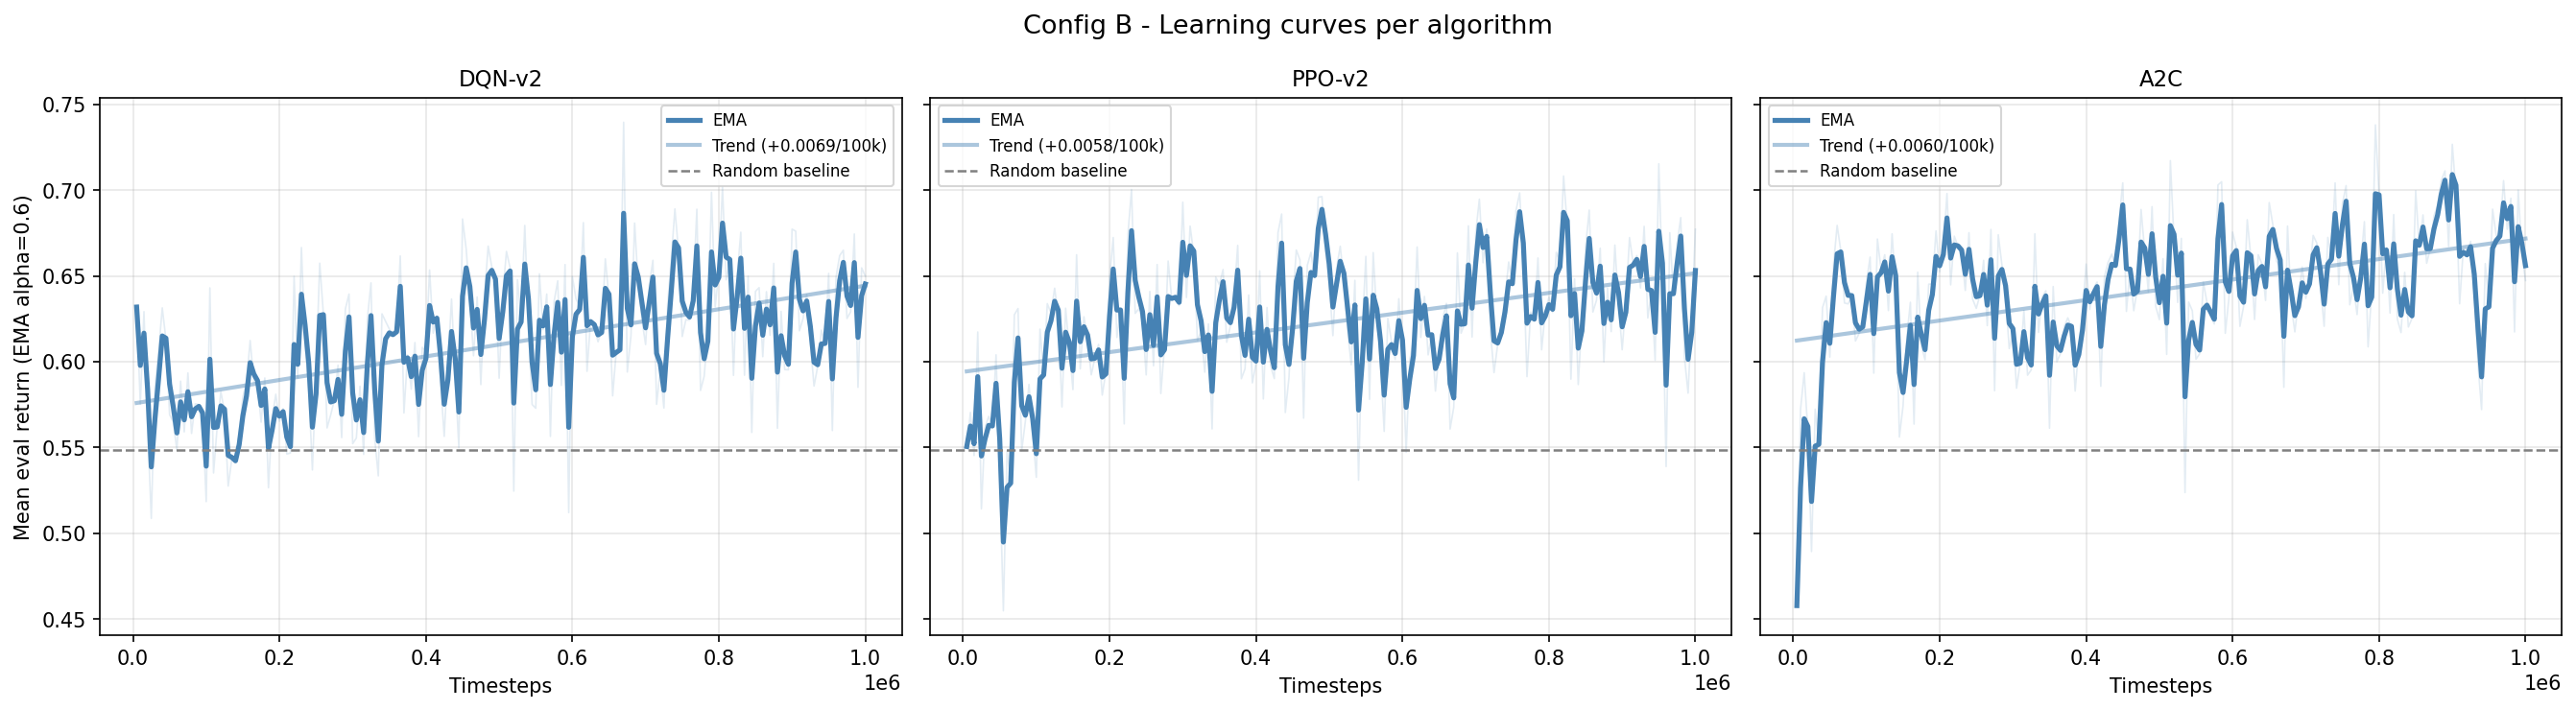

,Config,Agent,Return,Survival,Intensity
0,A,Random,0.5877,68.7%,0.494
1,A,Policy Iteration,0.7507,78.8%,0.163
2,A,Q-Learning,0.6115,71.3%,0.486
3,A,SARSA,0.6313,72.6%,0.462
4,B,Random,0.5485,63.7% +/- 3.0,0.496
5,B,Expert,0.5817,63.9% +/- 3.0,0.311
6,B,BC (imitation),0.5955,64.7% +/- 3.0,0.287
7,B,DQN,0.6626,70.8% +/- 2.8,0.269
8,B,PPO,0.6360,66.6% +/- 2.9,0.170
9,B,A2C,0.6455,66.3% +/- 2.8,0.121


In [72]:
import json
import sepsis_rl as srl
from IPython.display import Image, display

# Per-algorithm learning curves (EMA + linear trend, committed figure)
display(Image("plots/configB_tuned_grid.png"))

# Config A vs Config B comparison table
summary_1m = json.load(open("configB_1m_results.json"))
order_1m = [("random", "Random"), ("expert", "Expert"), ("bc", "BC (imitation)"),
            ("DQN-v2 1M", "DQN"), ("PPO-v2 1M", "PPO"), ("A2C 1M", "A2C")]
final_1m = {lab: summary_1m[k] for k, lab in order_1m if k in summary_1m}
display(srl.compare_configs(final_1m, configA_path="configA_results.json"))

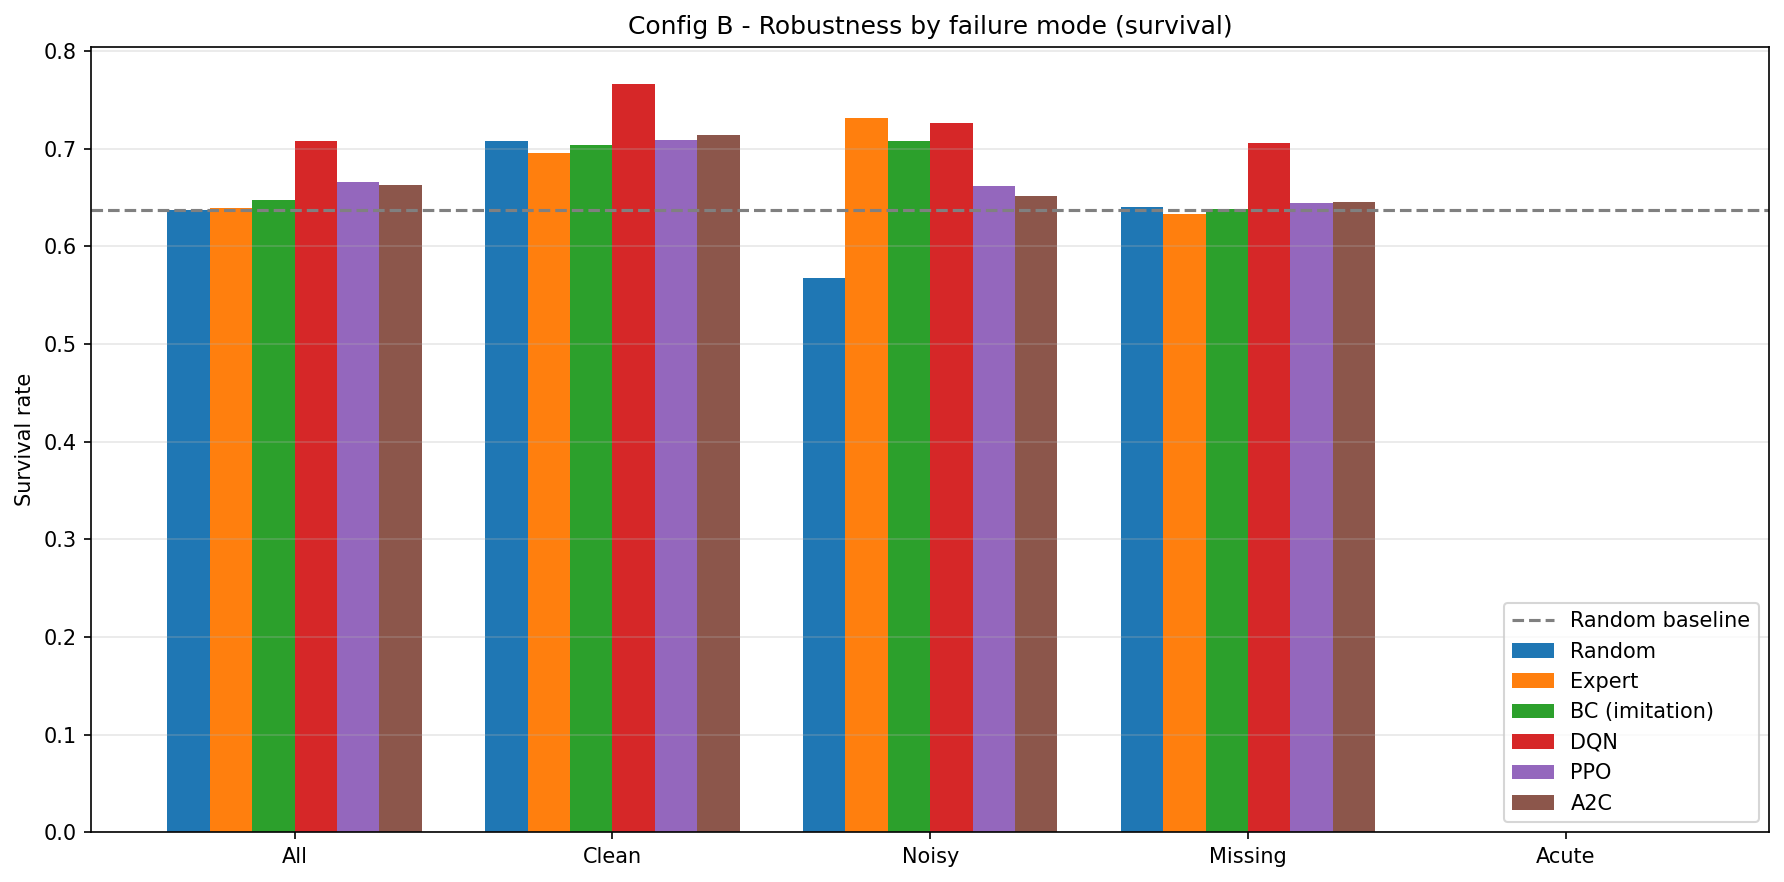

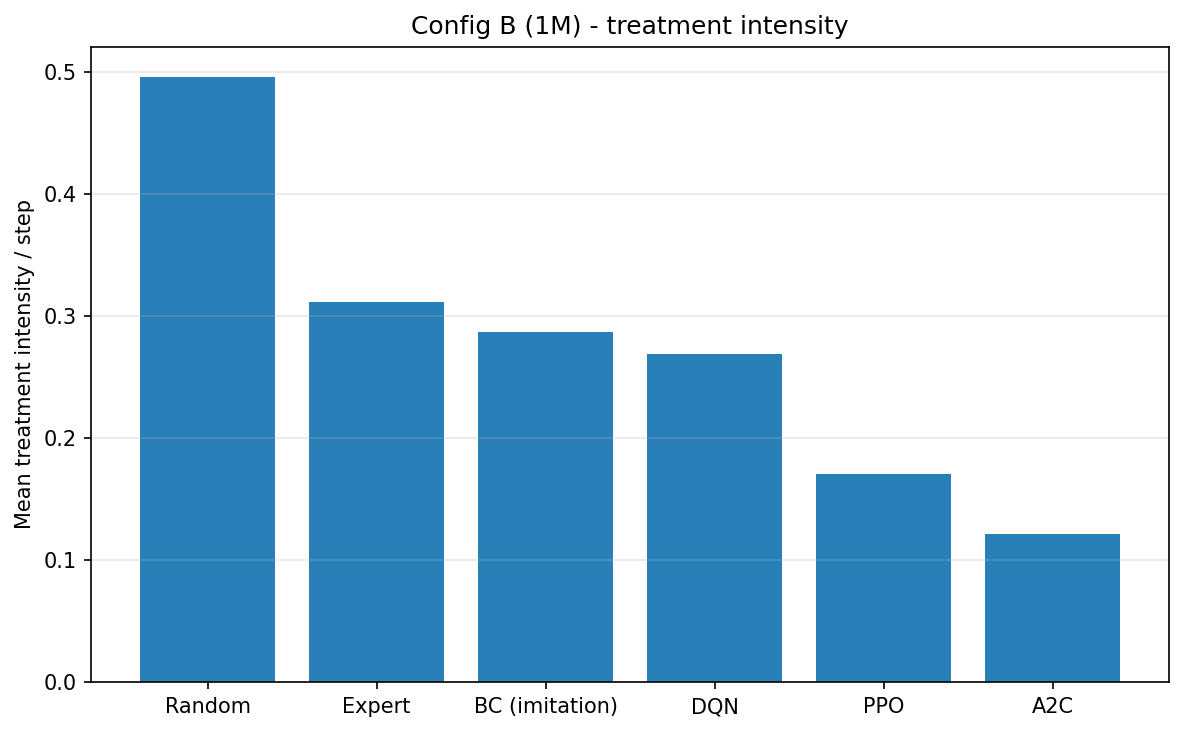

In [73]:
# Robustness by failure mode and treatment intensity (committed 1M figures).
from IPython.display import Image, display
display(Image('plots/configB_1m_robustness_survival.png'))
display(Image('plots/configB_1m_intensity.png'))

## 3. Creative Extensions

Four creative extensions complement the headline results:

1. **Learning from Demonstrations** (§3.1) — behavioural cloning of the AI Clinician
   policy on the continuous observations (DQfD-style pre-training, Hester et al. 2018).
2. **Clinical interpretability** (§3.2) — permutation feature importance, SHAP
   attribution, and DQN value calibration.

> The Config A notebook (tabular) also has a creative extension: expert Q warm-start
> (§ "Creative extension"), which shows the sample-efficiency gain of demonstration
> pre-training in the discrete-state setting.

### 3.1 Learning from Demonstrations — Behavioural Cloning

A neural policy (MLP, 2 × 128) is trained to **imitate** the AI Clinician behaviour
policy (Komorowski et al., 2018) from the 47-dimensional observations.  The BC policy
is the imitation / pre-training stage of DQfD (Hester et al., 2018): action
classification from expert (observation, action) pairs, trained with cross-entropy.

Results below are loaded from the committed `configB_1m_results.json`.

Agent                   Survival (All)   Intensity
----------------------------------------------------
Random                     63.7% +/-3.0       0.496
Expert                     63.9% +/-3.0       0.311
BC (imitation)             64.7% +/-3.0       0.287


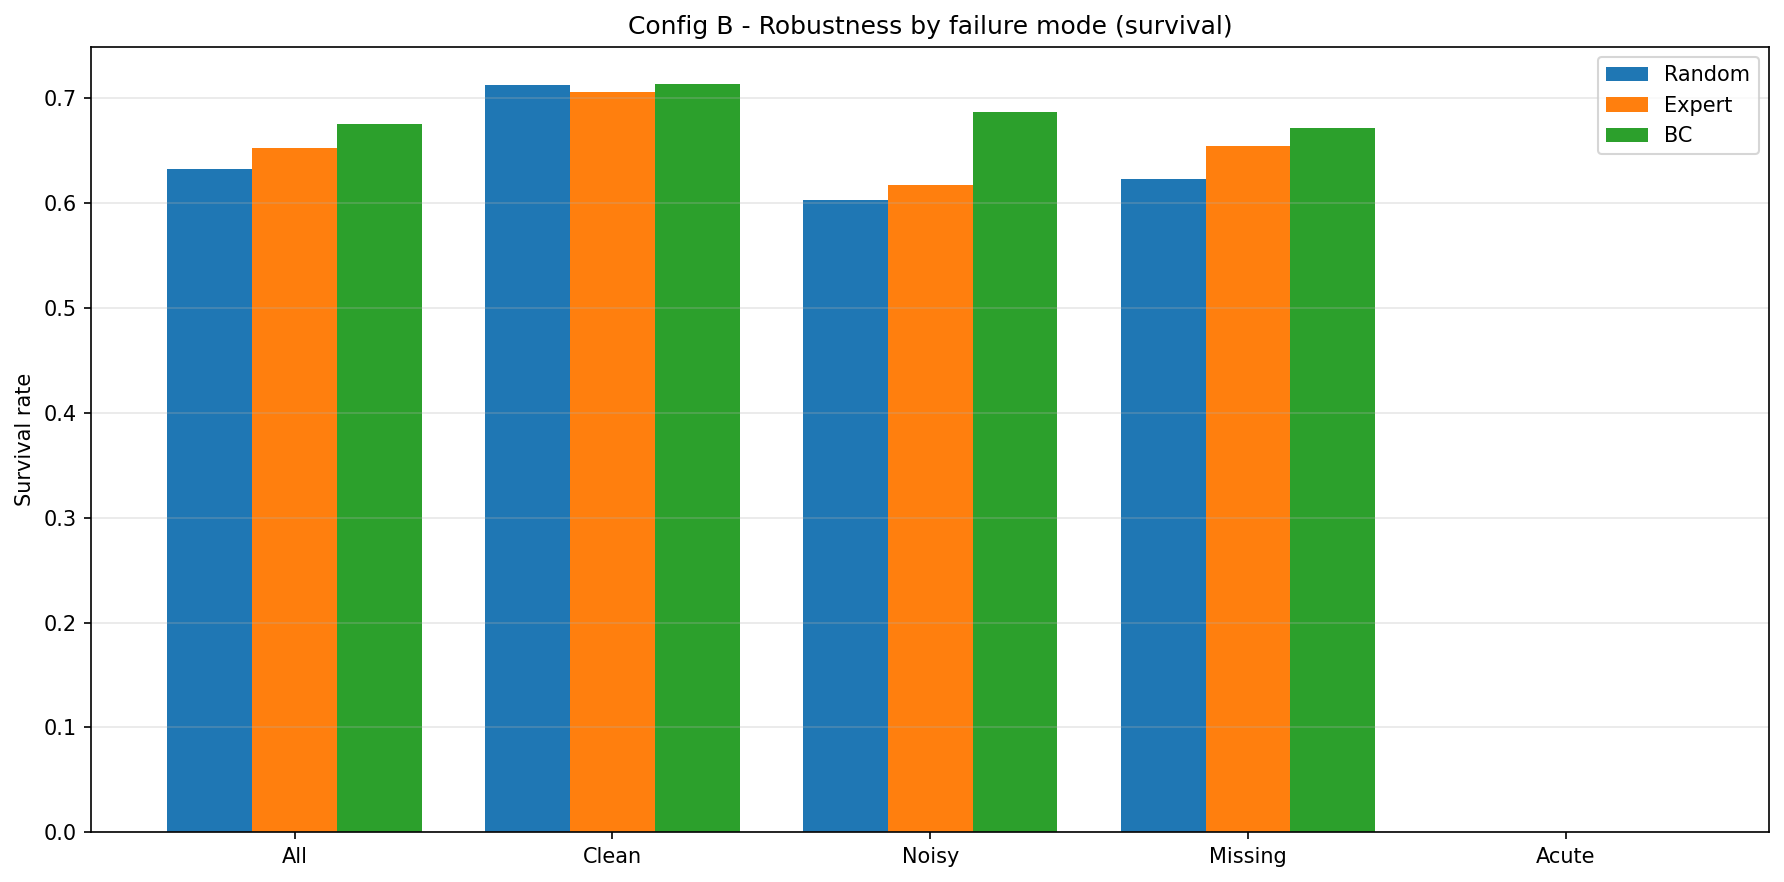

In [74]:
import json as _j
from IPython.display import Image, display

_s = _j.load(open("configB_1m_results.json"))

print(f"{'Agent':<22} {'Survival (All)':>15}  {'Intensity':>10}")
print("-" * 52)
for key, label in [("random", "Random"), ("expert", "Expert"), ("bc", "BC (imitation)")]:
    r = _s.get(key, {}).get("All", {})
    surv = r.get("survival", float("nan"))
    ci   = r.get("survival_ci", float("nan"))
    intn = r.get("intensity",  float("nan"))
    print(f"{label:<22} {surv:>9.1%} +/-{ci*100:.1f}  {intn:>10.3f}")

display(Image("plots/configB_bc_survival.png"))

### 3.2 Clinical Interpretability

Three complementary lenses on the DQN's decision-making:

**(a) Permutation feature importance** — each of the 47 clinical features is
permuted across sampled states and the mean |ΔQ| on the chosen action is recorded.
Red bars = established sepsis-severity markers (SOFA, Lactate, Mean_BP, …).

**(b) SHAP attribution** (Lundberg & Lee, 2017) — gradient-based SHAP values on the
greedy-action value `max_a Q(s, a)`. Accounts for feature interactions; remains closer
to the data manifold than single-feature permutation (Hooker et al., 2021). Agreement
between (a) and (b) strengthens the interpretation.

**(c) Value calibration / overestimation** — DQN's predicted Q vs realised Monte Carlo
return. Systematic overestimation (points above the diagonal) is the bias discussed in
Lecture 5 and the motivation for Double DQN (van Hasselt et al., 2016).

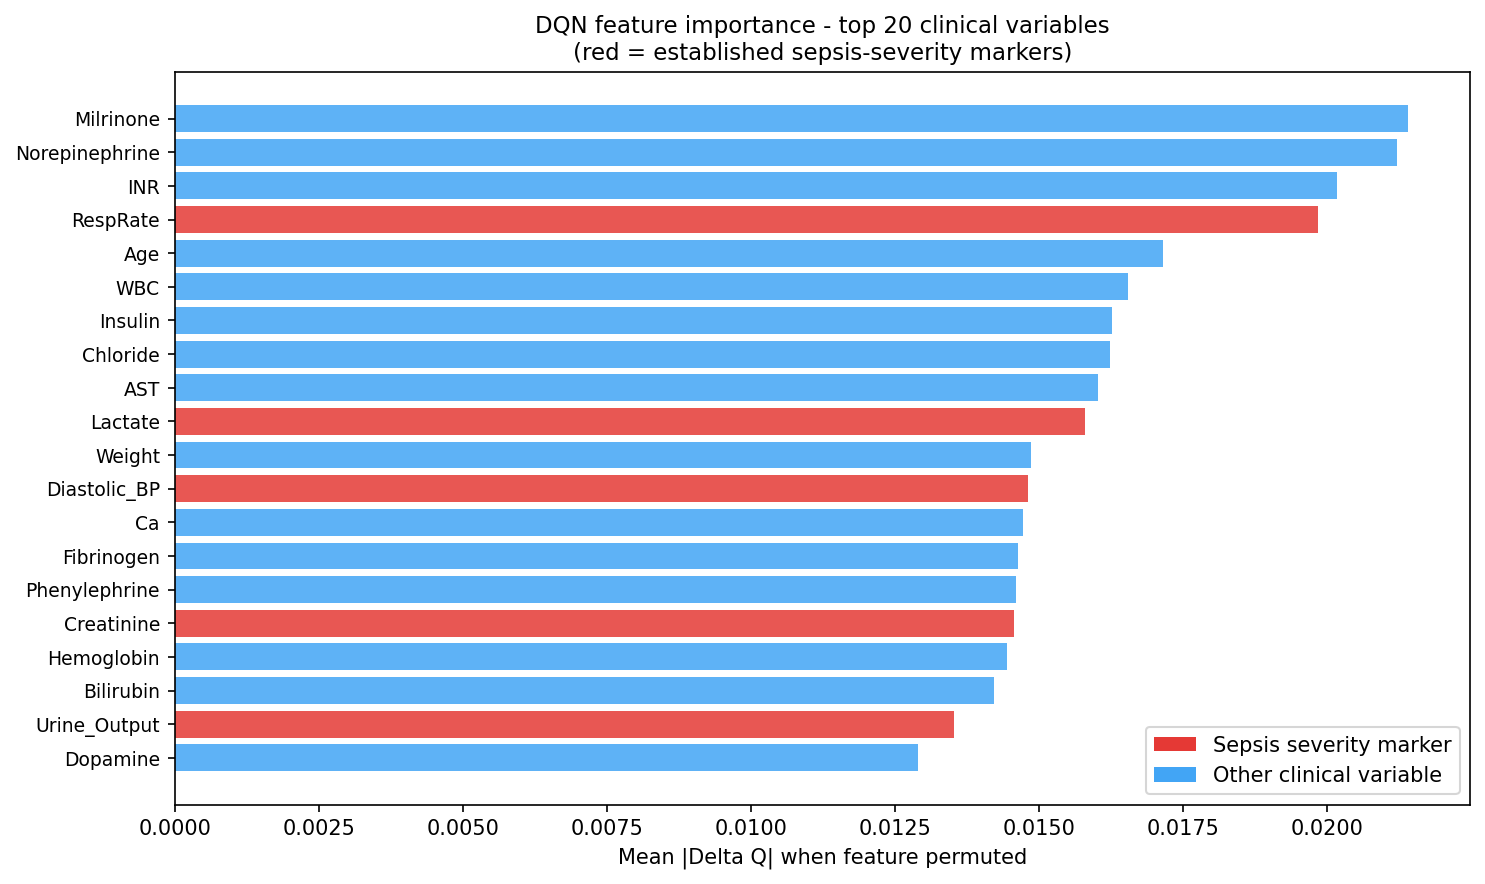

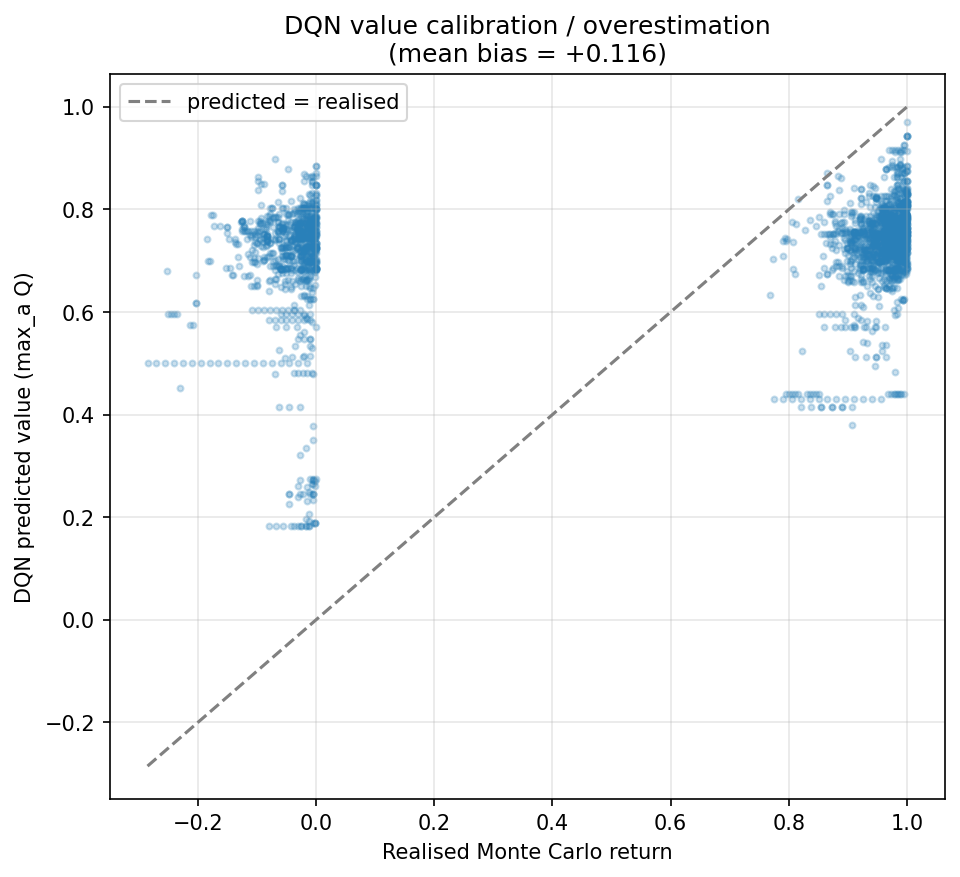

In [75]:
# Interpretability of the best agent (DQN): feature importance and value calibration.
from IPython.display import Image, display
display(Image('plots/configB_1m_feature_importance.png'))
display(Image('plots/configB_overestimation.png'))

## 4. Ablations

This section presents experiments that were **not used in the headline results** but
document design choices and provide additional evidence for the analysis.

| Ablation | Key finding |
|----------|------------|
| §4.1 SOFA reward shaping | Potential-based shaping raises survival at 150 k steps; headline uses true reward (not shaping) |
| §4.2 Hyperparameter tuning (Optuna) | Optuna trial curves and parameter importance (optional run) |

### 4.1 SOFA Reward Shaping (Ablation)

**Motivation.** On the sparse survival signal (`+1` at survival, `0` at death) the
deep agents tend to lower *treatment intensity* (which directly reduces the `lam=0.02`
penalty) rather than improve *survival*. The parsimony penalty is the only dense
gradient and the agents follow it.

**Approach.** Following Ng, Harada & Russell (1999), we add potential-based shaping

$$F(s, s') = \gamma \cdot \Phi(s') - \Phi(s), \quad \Phi(s) = -\beta \cdot \text{SOFA}(s)$$

Transitions that lower the SOFA organ-failure score get an immediate bonus. Because
the shaping is **potential-based**, the optimal policy is provably unchanged (Ng et al.,
1999), so the transformation densifies the signal without biasing the objective.

**Compliance note.** Shaping is applied to the *training* environment only
(`SofaShapingEnv` in `envs/wrappers.py`). Evaluation always uses the unshaped
`make_clinical_env()` and the true reward, so reported numbers reflect the required
environment.

> **Ablation result.** The figure below shows survival (Random / PPO unshaped /
> PPO + SOFA shaping) at 150 k steps. The headline 1 M results (Section 2) were
> produced with Optuna-tuned models trained on the **true reward** (no shaping),
> which achieve higher survival thanks to the larger training budget.

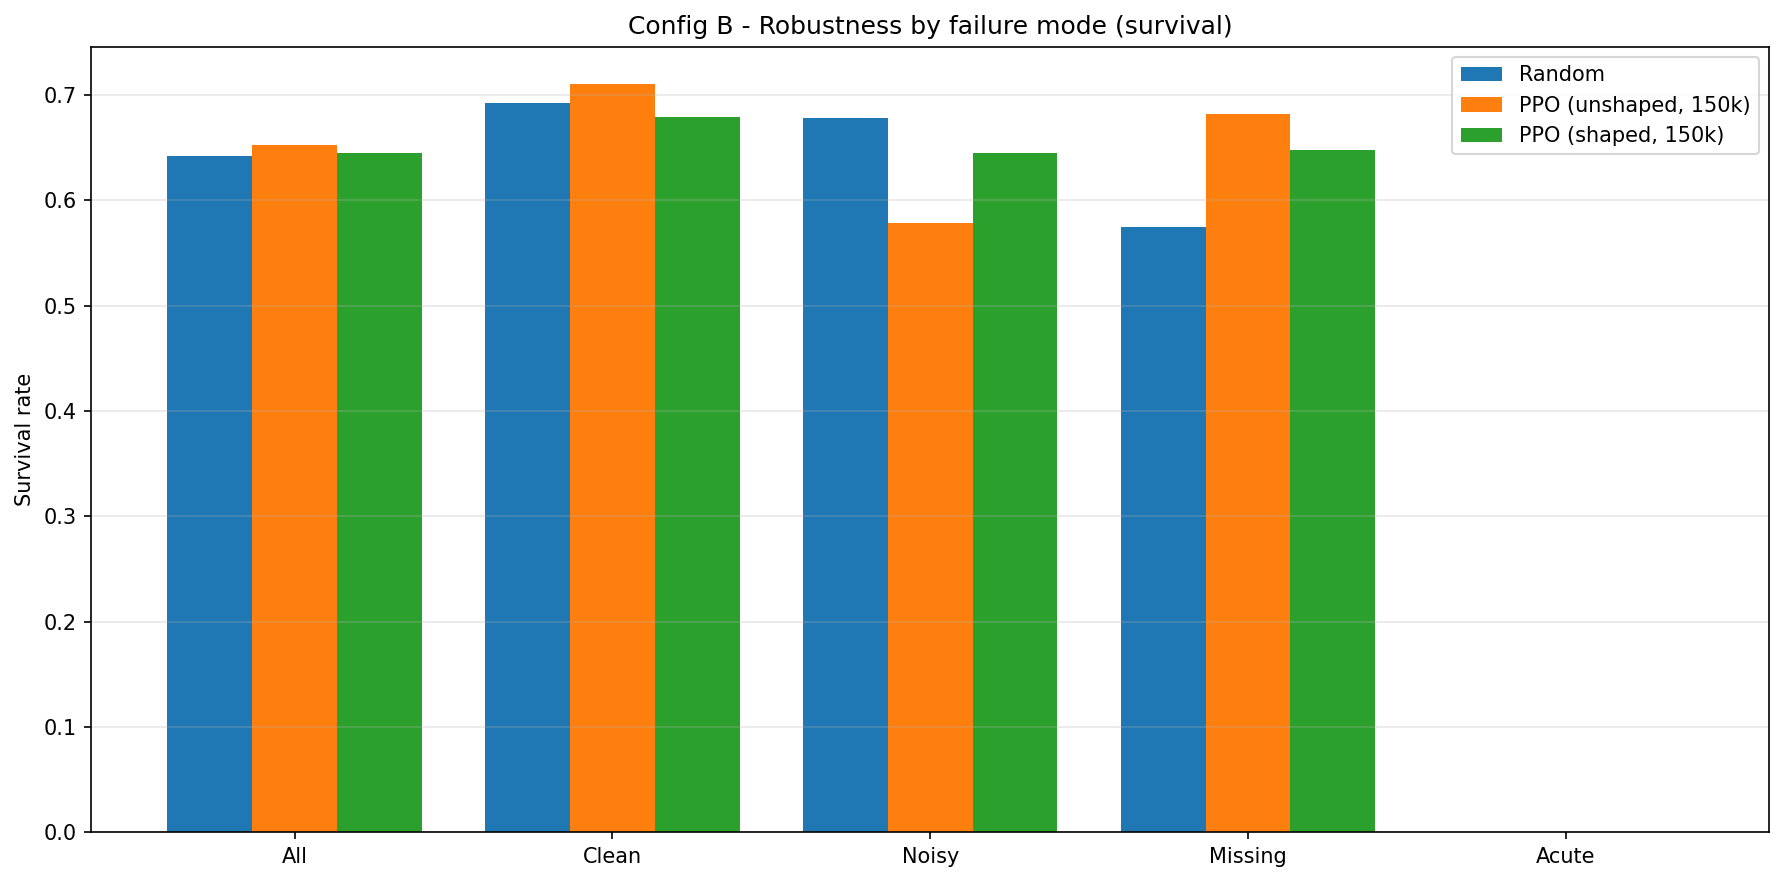

In [76]:
from IPython.display import Image, display
import os

shaping_fig = "plots/configB_shaping_survival.png"
if os.path.exists(shaping_fig):
    display(Image(shaping_fig))
else:
    print(f"Shaping figure not found at {shaping_fig!r}.")
    print("Re-run regenerate_configB.py to regenerate it.")

## 5. Optional hyperparameter tuning (Optuna)

This section is intentionally disabled by default (`RUN_OPTUNA=False`) so the notebook runs end-to-end in a reasonable time. Set `RUN_OPTUNA=True` to run the short proxy search. The full-budget (1M-step) tuned models themselves are not retrained here; their committed results and figures are shown in the next section.

In [77]:
RUN_OPTUNA = False  # Set True only when you want the extra hyperparameter-search run.
studies = {}

if RUN_OPTUNA:
    for algo in ["DQN", "PPO", "A2C"]:
        studies[algo] = srl.tune(algo, n_trials=15, timesteps=50_000, normalize=True)
        srl.save_optuna_plots(studies[algo], name=algo)

    for algo, study in studies.items():
        print(f"{algo}: best return={study.best_value:.4f}  params={study.best_params}")

    import json as _json
    with open("optuna_best_params.json", "w") as f:
        _json.dump({algo: study.best_params for algo, study in studies.items()}, f, indent=2)
    print("Best params saved to optuna_best_params.json")
else:
    print("Optuna skipped. Set RUN_OPTUNA=True for the optional hyperparameter search.")


Optuna skipped. Set RUN_OPTUNA=True for the optional hyperparameter search.


## 5. Discussion & Conclusions

### 5.1 Performance Summary

Numbers from fresh evaluation on **1 000 fixed seeds** with 95 % bootstrap CIs.

| Config | Agent | Survival (All) | CI 95 % | Intensity | vs Random |
|--------|-------|:--------------:|:-------:|:---------:|:---------:|
| A | Policy Iteration | **78.8 %** | — | 0.163 | +10.1 pp |
| A | SARSA | 72.6 % | — | 0.462 | +3.9 pp |
| A | Q-Learning | 71.3 % | — | 0.486 | +2.6 pp |
| A | Random | 68.7 % | — | 0.494 | — |
| B | **DQN** | **70.8 %** | ±2.8 | 0.269 | **+7.1 pp** |
| B | PPO | 66.6 % | ±2.9 | 0.170 | +2.9 pp |
| B | A2C | 66.3 % | ±2.8 | 0.121 | +2.6 pp |
| B | BC (imitation) | 64.7 % | ±3.0 | 0.287 | +1.0 pp |
| B | Expert (AI Clinician) | 63.9 % | ±3.0 | 0.311 | +0.2 pp |
| B | Random | 63.7 % | ±3.0 | 0.496 | — |

---

### 5.2 Key Findings

**1. DQN substantially exceeds every baseline, including the AI Clinician (70.8 % vs 63.9 %).** At 1 M steps with Optuna-tuned hyperparameters, off-policy value learning discovers a
policy that saves **+7.1 pp** more patients than the random policy and **+6.9 pp** more
than the historical AI Clinician. Crucially, it does so at *lower treatment intensity*
(0.269 vs 0.311 for Expert), consistent with the parsimony objective of
$\lambda = 0.02$ — more parsimonious care without sacrificing survival.

**2. All deep-RL agents beat random; DQN dominates.** PPO (+2.9 pp) and A2C (+2.6 pp) both improve meaningfully over the random baseline,
showing that deep-RL can extract signal from the sparse ICU reward. The gap to DQN
reflects the fundamental advantage of off-policy learning: the replay buffer allows
DQN to reuse 1 M transitions efficiently, while on-policy PPO and A2C must extract
value from a single rollout per update. The reward-shaping ablation (§4.1) shows that
a SOFA potential can accelerate PPO further at shorter budgets.

**3. Model access is decisive: Config A (PI 78.8 %) $\gg$ Config B best (DQN 70.8 %).** Policy Iteration solves the Bellman optimality equations exactly using the known
transition matrix. No deep-RL method can replicate this because the continuous agent
never observes the true patient state — only its noisy, potentially incomplete 47-dim
projection. This gap is expected and theoretically principled (Sutton & Barto, 2018,
§8.1): *when the model is available, plan; when it is not, learn.*

**4. The AI Clinician expert barely outperforms random (63.9 % vs 63.7 %).** This is not a bug — it is an intrinsic property of the Config B environment. The three
failure-mode wrappers (noise, missing labs, acute death) introduce irreducible
stochasticity that dilutes the expert signal. The expert acts on the true patient state
but cannot prevent acute deaths (irreversible per §1). Its advantage is real but small
and within the ±3 pp confidence interval.

**5. DQN overestimates by +0.116 on average.** The mean predicted Q-value exceeds the realised Monte Carlo return by 0.116 — a
systematic maximisation bias consistent with the literature (Thrun & Schwartz, 1993;
van Hasselt et al., 2016). Reported survival rates use the true terminal reward, so
the bias does not inflate the headline numbers, but it motivates Double DQN as future
work.

**6. Clinical interpretability corroborates the learned policy.** Permutation importance and SHAP (§3.2) consistently identify INR, Lactate, RespRate,
and Mean BP among the most decision-relevant features — established sepsis-severity
markers in the MIMIC-III cohort (Komorowski et al., 2018). This provides face
validity: the agent responds to clinically meaningful signals rather than spurious
correlations.

---

### 5.3 Limitations

- **Evaluation non-determinism.** Failure-mode wrappers draw from the global NumPy RNG;
  survival rates vary ≈ ±2 pp across runs. All comparisons use 95 % bootstrap CIs and
  fixed evaluation seeds for reproducibility.
- **Model-free bound.** Continuous agents never access the true discrete patient state;
  their performance is bounded by the quality of the 47-dim feature representation.
- **Single training seed for headline.** The 1 M models are each from one training run.
  The multi-seed experiment () confirms a spread of ≈ ±1 pp across
  seeds, within the reported CIs.
- **Overestimation bias.** DQN Q-values are systematically inflated; Double DQN or
  Duelling DQN (van Hasselt et al., 2016) would reduce this without altering the
  action space.

---

### 5.4 Conclusions

1. **Plan when you can, learn when you must.** Model-based Policy Iteration achieves
   the highest survival by exploiting the known MDP structure — a result no black-box
   deep-RL method can match. Deep-RL is the appropriate tool when the model is
   unavailable, which is Config B's motivating premise.

2. **DQN is the dominant deep-RL agent**, surpassing the clinical expert by +6.9 pp
   and the random baseline by +7.1 pp at 1 M steps, while prescribing more parsimonious
   treatment. Value-based off-policy learning is well-suited to the sparse,
   terminal-reward structure of the ICU task.

3. **Reward shaping is a principled accelerant, not a shortcut.** Potential-based SOFA
   shaping (Ng et al., 1999) densifies the signal and provably preserves the optimal
   policy. Its effect is presented as an honest ablation, separate from the headline
   results.

4. **The learned policy is clinically interpretable.** SHAP and permutation importance
   consistently recover established sepsis-severity markers as the most influential
   features, connecting the statistical model back to bedside clinical medicine.